<a href="https://colab.research.google.com/github/DaeYejun2/ML_Notes/blob/main/ML_class7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees

## Decision Tree

Cat Classification Example

고양이 입양 센터 -> 고양이 분류 모델

CV와 test sets 모두에서 잘 동작하는지

그렇다면 어떻게 학습 시키는가?

1. root node로 쓸 feature를 결정
2. 그 다음 분류를 위한 최적의 feature들 설정
3. 분류
4. 반복

key decisions: 언제 분류할 것인가.

1. purity(순수도?): purity를 최대화 (혹은 impurity 최소화) -> 어떤 feature가 가장 최대의 purity를 주는가?
2. splitting 멈추는 경우
* node가 100% 하나의 class일 때
* 최대 depth에 도달
* 순수도 점수가 좋아지지 않을 때
* 샘플 갯수가 너무 적은 경우

-> 주로 더 해도 이득을 못 보는 경우

## Decision Tree Learning

순수도를 먼저 측정한다. -> 모든 샘플이 cat이 거나, 하나의 클래스만 남았다. 이것은 매우 purity하다.

어떻게 정량적으로 측정할 것인가.

-> Entropy. 불확실성 50:50 으로 예측하기 어려운 경우에 엔트로피가 올라간다. 반면, 전부다 고양이인 경우에는 엔트로피가 0이 됨

p1 = fraction of examples that are cats

ADsP 엔트로피 구하는거랑 같음

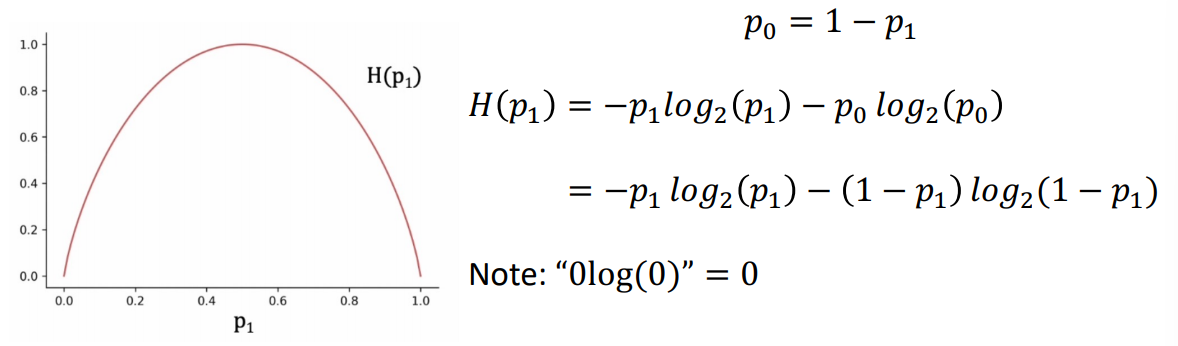

Information Gain

엔트로피를 좋아하지 않는다. = 엔트로피를 낮출 수 있는 선택

결정트리의 학습 알고리즘은 불확실성이 낮아질 수 있는 feature 선택

이를 information gain이라고 함

Choosing a Split

feature 바꿔가며 엔트로피 가장 낮은 feature 고르기

+Weighed average: 샘플 수에 관련되도록 가중치를 준다?

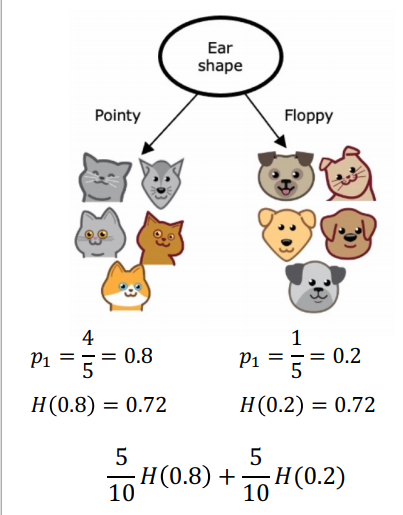

이런식으로 10마리중 5마리니까 엔트로피에 곱해줌

그러고 전단계의 엔트로피(H(0.5)) - 가중평균을 해줌

그렇게 나온 가장 높은 값을 feature로 선택

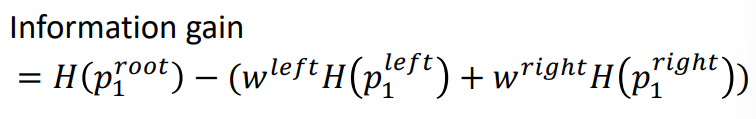

1. root node부터 시작 - 모든 샘플부터
2. 가능한 feature를 나열하고, split했을 때 얻을 수 있는 information gain을 구하고
3. 가능 높은 gain을 골라서 split
4. left, right branch 만들고
5. 반복

#### stop condition
1. 100% one class
2. tree dopth를 넘어갔을 때
3. information gain이 특정 임계값보다 낮게 됐을 때

recursive splitting

left branch를 root node라고 생각하고 information gain, 거기서 또 반복, 이런식으로 재귀를 이용해 순회하며 모든 노드 돌기

Maximum Depth Parameter

파라미터 튜닝으로 depth 지정

higher-degree polynomial or larger
neural network

너무 커지면 과적합이 될 수도 있다.

feature가 두 개이상의 value를 가졌을 경우

Ear shape를 여러개의 feature로 나누기

Ear shape(pointy, floppy) -> (point ears, Floppy ears, Oval ears)

이를 One Hot Encoding이라고 함

feature가 k개의 value를 가질 때 k binary feature를 만들어라

neural networks에서도 적용 가능하다 0 또는 1로 바꾸면

continuous features:
 weight < 8 lbs, weight < 10 lbs, weight < 8 lbs ... 이런식으로 가장 높은거 고르기

 n개의 examples가 있으면, n-1개 만큼의 임계값 그 후보, 그 중 가장 높은거로

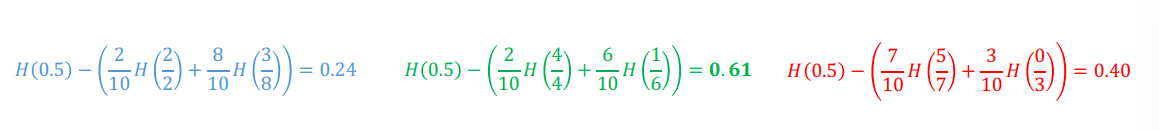

0.61


### Regression Trees

결정 트리를 숫자 예측에 적용할 수 있을 까

마지막 leaf node를 숫자로 와야 한다. 예를 들어 마지막을 weights로 놓고, 그 값들 평균으로 넣는다.

마지막에 따라 어떤 트리인가가 달라지는 듯

이젠 Variance를 본다.

root 노드가 20.51 일 때, 아래로 가면서 분산이 낮아지면 OKAY

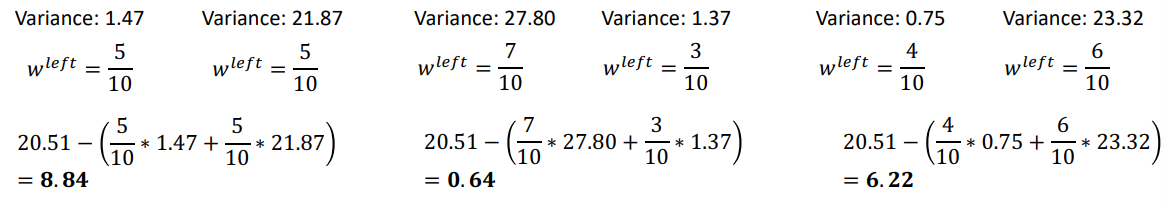

8.84를 선택 => 분산 감소량이기 때문에 가장 큰 값 선택

## Tree Ensembles

single tree는 데이터에 민감할 수 있다.

앙상블 ㄱㄱ

트리를 여러개 만들어서 보팅(투표 메커니즘)을 사용한다. -> 대다수의 모델이 cat이라고 판단하면 cat일 것이다.

voting 메커니즘으로 데이터에 민감하지 않게 판단 가능

구현

sampling with replacement - training dataset을 랜덤하게 바꿔주기 -> 여러 형태의 디시젼 트리를 만드는 아이디어(트레이닝 샘플 셋을 샘플링해서)

Sampling with replacement creates a new training set that is similar
to, but meaningfully different from, the original

-> tree의 feature 순서를 바꿔준다는거 같음

For b= 1 to B:

Bag에서 나온 만큼 반복 -> bagged decision tree

1000개 정도를 반복(B)는 그렇게 효율적이진 않다

64개 정도

n개의 피쳐중 몇개만 k개만 사용하는 방법 -> 랜덤 포레스트 알고리즘

-----

### Boosted Trees intuition

bagged 결정 트리를 B만 큼 반복

샘플링 -> 디시젼 트리: 너무 오래 걸릴 수 있다.

이걸 boosting 해준 것 -> 못 맞춘 애를 많이 학습해 가중치를 주는 식으로 해서 뽑힐 확률을 높이는 방식

오분류 한 애를 더 자주 뽑아서 성능을 높이기

Deliberate Practice

split한 트리가 많아질 수록 성능이 좋아질 것이다.
타겟해서 하는게 빠르고 효과적일 것이다.

XGBoost

오분류한 애들을 위주로 샘플링, 정규화, 등등 적용해서 성능 굳 - 전통 ml 임에도 자주 쓰임

분류 및 회귀로도 사용가능

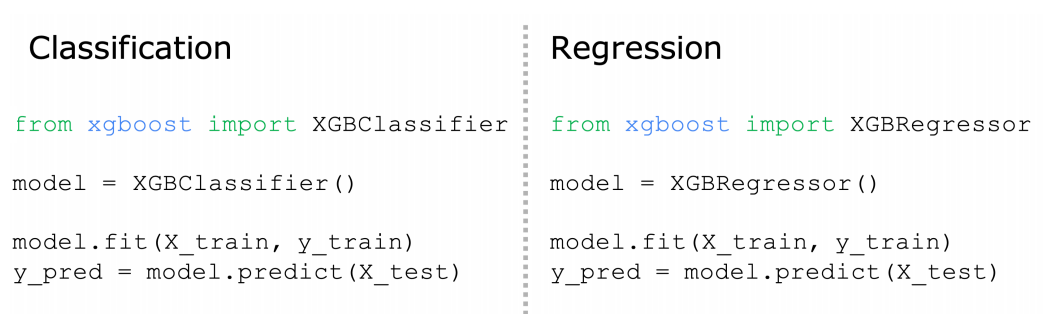